# Key Information Extraction from Financial Documents
## Exploratory Data Analysis

**Dissertation:** *Can small, locally-run language models match large LLMs at
extracting key fields from financial documents — and at what cost, speed, and
memory?* — Azhar Ali · M.Tech (AI & ML) · BITS `2024AA05791`

---

This deck explores the **two real datasets** behind the study and shows how each
observation drove a concrete design decision. Every number is computed live from the
project's own data layer (`src/`) — no hard-coded figures.

### Setup

In [1]:
import sys, json
from pathlib import Path

def _find_root(start: Path) -> Path:
    for p in [start, *start.parents]:
        if (p / 'src').exists() and (p / 'config' / 'config.yaml').exists():
            return p
    raise RuntimeError('repo root not found')

ROOT = _find_root(Path.cwd())
sys.path.insert(0, str(ROOT))

import pandas as pd
import matplotlib.pyplot as plt
%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 120, 'figure.figsize': (8, 4.2), 'font.size': 11,
    'axes.spines.top': False, 'axes.spines.right': False,
    'axes.grid': True, 'grid.alpha': 0.25, 'axes.axisbelow': True,
})
INK, ACC1, ACC2 = '#1f2a44', '#2f6df6', '#e8734a'   # neutral + two accents

from src.config import load_config, load_schema, schema_field_names
from src.data.loaders import load_dataset, available_datasets
from src.data.gt import load_test_set
from src.data.preprocess import from_dataset_record

cfg = load_config()
DATASETS = [d for d in ('sroie', 'kleister_charity') if d in available_datasets(cfg)] or ['sample']
TITLES = {'sroie': 'SROIE (receipts)', 'kleister_charity': 'Kleister-Charity (reports)', 'sample': 'sample (synthetic)'}
print('datasets in play:', DATASETS)

datasets in play: ['sroie', 'kleister_charity']


### 1 · The task — what each model must extract

The **schema is the ground truth of the task**: exact field names, types, and whether
a field is required. SROIE is *simple* (4 fields); Kleister-Charity is *complex* (8
fields). Field `type` later drives **type-aware** scoring (a date matches regardless of
format).

In [2]:
for name in DATASETS:
    schema = load_schema(cfg, name)
    rows = [{'field': f['name'], 'type': f.get('type', 'string'),
             'required': bool(f.get('required'))} for f in schema['fields']]
    print(f"\n{TITLES[name]} — {len(rows)} fields")
    display(pd.DataFrame(rows))


SROIE (receipts) — 4 fields


,field,type,required
0,company,string,True
1,date,date,True
2,address,string,True
3,total,currency,True



Kleister-Charity (reports) — 8 fields


,field,type,required
0,charity_name,string,True
1,charity_number,string,False
2,report_date,date,False
3,income_annually_in_british_pounds,currency,False
4,spending_annually_in_british_pounds,currency,False
5,address__post_town,string,False
6,address__postcode,string,False
7,address__street_line,string,False


### 2 · Corpus at a glance

How many documents back the study, split into **train** (fine-tuning + few-shot pool)
and **test** (the frozen benchmark). The test benchmark is deliberately small and
fixed; the train pool is large.

,train,test
SROIE (receipts),501,125
Kleister-Charity (reports),1729,440


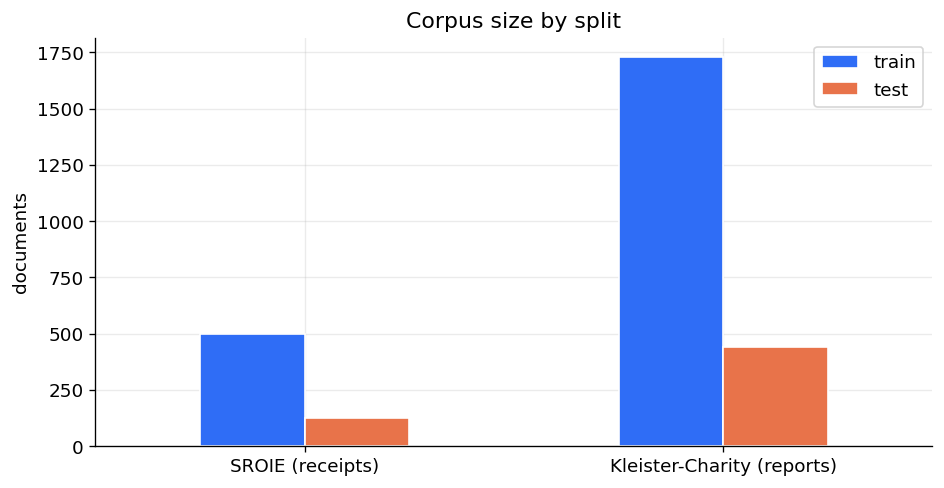

In [3]:
counts = {}
for name in DATASETS:
    row = {}
    for split in ('train', 'test'):
        try:
            row[split] = len(load_dataset(cfg, name, split=split))
        except Exception:
            row[split] = 0
    counts[TITLES[name]] = row
corpus = pd.DataFrame(counts).T
display(corpus)

ax = corpus.plot(kind='bar', color=[ACC1, ACC2], edgecolor='white')
ax.set_ylabel('documents'); ax.set_title('Corpus size by split'); ax.set_xlabel('')
plt.xticks(rotation=0); plt.tight_layout(); plt.show()

### 3 · The frozen 20-document test set

The whole benchmark runs on a **fixed, seeded** selection (10 SROIE + 10 Kleister).
Fixing it means every model — and every Phase-3 improvement — is judged on the *exact
same* documents, so deltas are attributable to the model, not the sample.

In [4]:
ts = load_test_set(cfg)
sel = pd.Series([s['dataset'] for s in ts['doc_ids']]).value_counts()
print(f"seed={ts['seed']}  synthetic={ts['synthetic']}  total={ts['count']}")
display(sel.rename('docs').to_frame())

seed=42  synthetic=False  total=20


,docs
sroie,10
kleister_charity,10


### 4 · Document length → the case for `max_input_lines: 120`

Small local models have small context windows and limited working memory (they run on
an 8 GB M1). Kleister charity reports have a **long tail** of hundreds of lines. Feeding
them verbatim would blow the context and cost. We cap the prompt at **120 lines** — the
marked line below — which covers the bulk of documents while bounding every prompt.

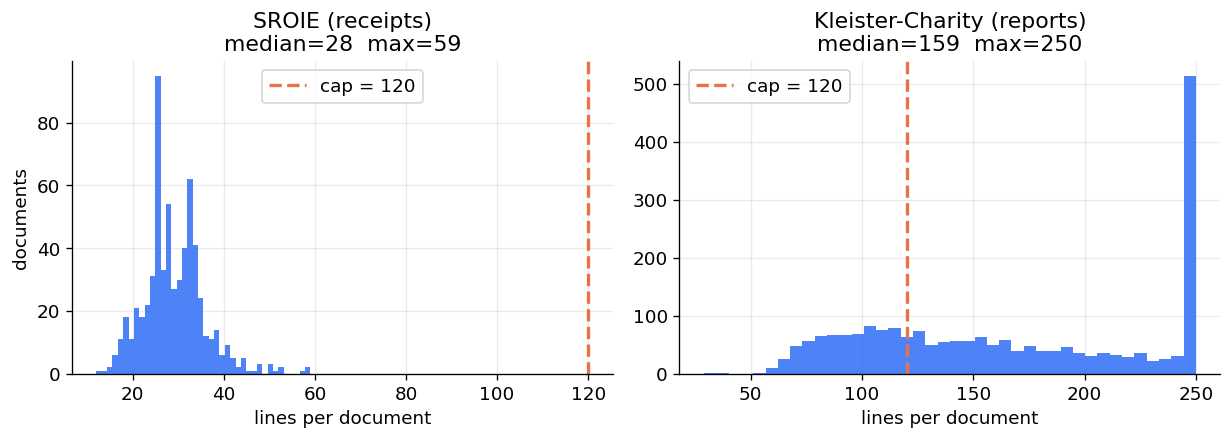

In [5]:
cap = cfg['conditions'].get('max_input_lines', 120)
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.2 * len(DATASETS), 3.8), squeeze=False)
for ax, name in zip(axes[0], DATASETS):
    lens = []
    for split in ('train', 'test'):
        try:
            lens += [len(from_dataset_record(r)['lines']) for r in load_dataset(cfg, name, split=split)]
        except Exception:
            pass
    ax.hist(lens, bins=40, color=ACC1, alpha=0.85)
    ax.axvline(cap, color=ACC2, lw=2, ls='--', label=f'cap = {cap}')
    med = pd.Series(lens).median()
    ax.set_title(f"{TITLES[name]}\nmedian={med:.0f}  max={max(lens) if lens else 0}")
    ax.set_xlabel('lines per document'); ax.legend()
axes[0][0].set_ylabel('documents'); plt.tight_layout(); plt.show()

### 5 · Field fill-rates → the case for a **recall-aware** study

A field can only be extracted if it is actually *present* in the document. Required
fields appear almost always; several Kleister fields are **sparsely populated**. That
makes **recall** (did the model find the fields that exist?) as important as precision —
and motivates the Phase-3 recall techniques.

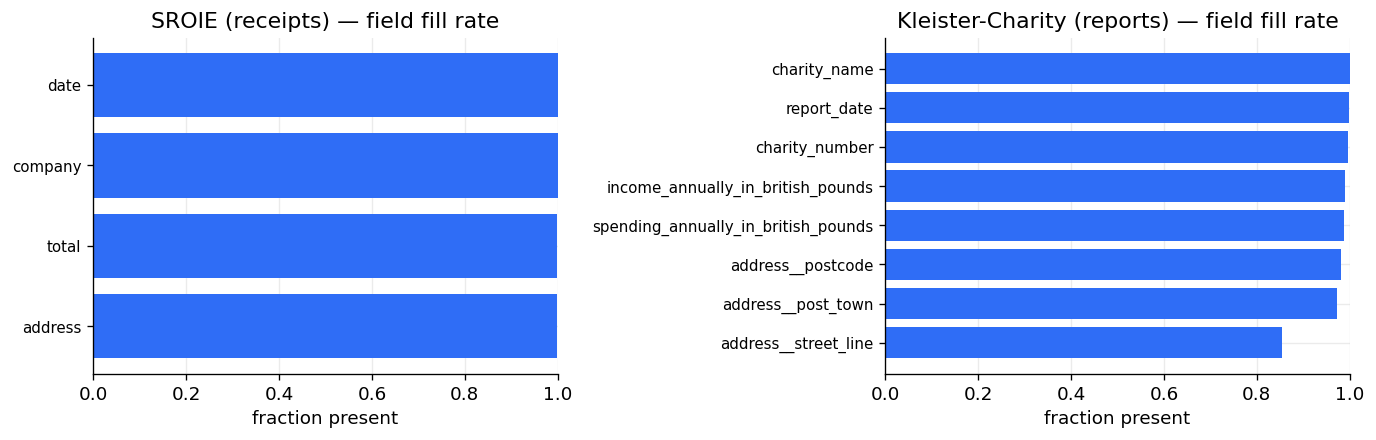

In [6]:
fig, axes = plt.subplots(1, len(DATASETS), figsize=(5.8 * len(DATASETS), 3.8), squeeze=False)
for ax, name in zip(axes[0], DATASETS):
    fields = schema_field_names(load_schema(cfg, name))
    recs = []
    for split in ('train', 'test'):
        try:
            recs += load_dataset(cfg, name, split=split)
        except Exception:
            pass
    rates = {f: sum(1 for r in recs if r.get('gold', {}).get(f) not in (None, '')) / max(len(recs), 1)
             for f in fields}
    s = pd.Series(rates).sort_values()
    ax.barh(range(len(s)), s.values, color=[ACC2 if v < 0.6 else ACC1 for v in s.values])
    ax.set_yticks(range(len(s))); ax.set_yticklabels(s.index, fontsize=9)
    ax.set_xlim(0, 1); ax.set_title(f"{TITLES[name]} — field fill rate"); ax.set_xlabel('fraction present')
plt.tight_layout(); plt.show()

### 6 · Value formats → the case for **type-aware** normalization

The same fact is written many ways: `£1,250` / `1250.00`, `15/APR/2017` /
`2017-04-15`. Exact string-match would wrongly penalise a correct value. So scoring
normalises **by type** (currency, date, number) identically for gold and prediction.

In [7]:
name = 'kleister_charity' if 'kleister_charity' in DATASETS else DATASETS[0]
schema = load_schema(cfg, name)
recs = load_dataset(cfg, name, split='test')
examples = {}
for f in schema['fields']:
    vals = [str(r['gold'][f['name']]) for r in recs if r.get('gold', {}).get(f['name'])][:4]
    if vals:
        examples[f"{f['name']} ({f.get('type','string')})"] = ', '.join(vals)
for k, v in examples.items():
    print(f"  {k:<48} e.g.  {v}")

  charity_name (string)                            e.g.  Wormington Village Society, Havens Christian Hospice, Cheltenham Ladies College, The Sanata Charitable Trust
  charity_number (string)                          e.g.  1155074, 1022119, 311722, 1132766
  report_date (date)                               e.g.  2018-07-31, 2016-03-31, 2016-07-31, 2015-12-31
  income_annually_in_british_pounds (currency)     e.g.  10348000.00, 32168000.00, 255653.00, 122836.00
  spending_annually_in_british_pounds (currency)   e.g.  9415000.00, 27972000.00, 258287.00, 124446.00
  address__post_town (string)                      e.g.  BROADWAY, WESTCLIFF-ON-SEA, CHELTENHAM, SHREWSBURY
  address__postcode (string)                       e.g.  WR12 7NL, SS0 8HX, GL50 3EP, SY3 7PQ
  address__street_line (string)                    e.g.  47 SECOND AVENUE, BAYSHILL ROAD, 58 TRINITY STREET, FURLONG ROAD


### 7 · Few-shot pool → no leakage

Few-shot prompting (`few_shot_k`) draws exemplars from the **train** split only, never
the 20-doc test set. This confirms both datasets have ample disjoint examples — the same
train/test boundary that Phase-3 fine-tuning depends on.

In [8]:
test_ids = {str(s['doc_id']) for s in load_test_set(cfg)['doc_ids']}
for name in DATASETS:
    try:
        train_ids = {str(r['doc_id']) for r in load_dataset(cfg, name, split='train')}
    except Exception:
        train_ids = set()
    print(f"{TITLES[name]:<32} train pool={len(train_ids):>5}  overlap with test={len(train_ids & test_ids)}")

SROIE (receipts)                 train pool=  501  overlap with test=0
Kleister-Charity (reports)       train pool= 1729  overlap with test=0


### 8 · EDA → design decisions

| Observation | Design decision it drives |
|---|---|
| Kleister reports have a long line-count tail | **`max_input_lines: 120`** — bound context & cost |
| Several fields are sparsely present | **Recall-aware** metrics; Phase-3 recall techniques |
| Values appear in many surface forms | **Type-aware normalization** (currency/date/number) |
| Large, disjoint train pool | Safe **few-shot** exemplars *and* **QLoRA fine-tuning** |
| Small fixed test set | **Frozen 20-doc benchmark** — attributable before→after deltas |

→ Next: `05_demo_detailed.ipynb` walks one document through the full pipeline and scales
to the 20-doc SLM-vs-LLM comparison.